MACHINE LEARNING
Seminar 2

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import io
import random
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Part I: Data preparation & analysis

In [2]:
df = pd.read_csv('Train_skelletonpoints.csv', sep=',', header=None)
display(df.head(10))

FileNotFoundError: [Errno 2] No such file or directory: 'Train_skelletonpoints.csv'

Create a function/script that takes SkelletonPoints as input and plots the corresponding pose. Your plotting function should also display the label associated with the pose being plotted.

In [ ]:
print(df.iloc[0:2].values)

[[1.3603e+02 1.9872e+02 1.9499e+02 2.4176e+02 2.0130e+02 2.0246e+02
  2.7833e+02 3.5128e+02 3.5128e+02 4.5827e+02 5.6526e+02 3.5614e+02
  4.5827e+02 5.5554e+02 1.2469e+02 1.2620e+02 1.3792e+02 1.4050e+02
  2.2430e+02 2.2111e+02 2.8305e+02 3.4968e+02 2.8804e+02 1.5917e+02
  1.2821e+02 1.4280e+02 2.5465e+02 2.4979e+02 2.5952e+02 1.8657e+02
  1.6711e+02 1.7198e+02 2.3698e+02 2.0880e+02 2.5767e+02 1.9100e+02
  8.9233e-01 6.6412e-01 6.4404e-01 7.6874e-01 7.3817e-01 6.8419e-01
  8.7514e-01 8.8166e-01 6.8862e-01 7.8250e-01 6.8072e-01 6.2456e-01
  6.8884e-01 7.7941e-01 8.3174e-01 8.4054e-01 7.9928e-01 6.6782e-01]
 [2.0242e+02 2.5999e+02 2.5588e+02 3.1345e+02 2.9700e+02 2.6410e+02
  3.1756e+02 3.8746e+02 3.8335e+02 4.7381e+02 5.6016e+02 3.8746e+02
  4.7381e+02 5.6016e+02 1.9420e+02 1.9420e+02 2.0653e+02 2.0653e+02
  2.5328e+02 2.4300e+02 2.9851e+02 3.4785e+02 3.0673e+02 1.8749e+02
  1.6281e+02 1.5870e+02 2.7795e+02 2.7384e+02 2.7795e+02 2.1627e+02
  2.2861e+02 2.3683e+02 2.6561e+02 2.4094e+02 2

In [ ]:
def plot_pose(Skpoints):
    x_points = []
    y_points = []
    for i in range(18):
        x_points.append(Skpoints[i])
        y_points.append(Skpoints[18+i])

    plt.plot(x_points, y_points, marker='o', linestyle='-')
    plt.xlabel('X points')
    plt.ylabel('Y points')
    plt.title('Pose')
    plt.grid(True)
    plt.show()

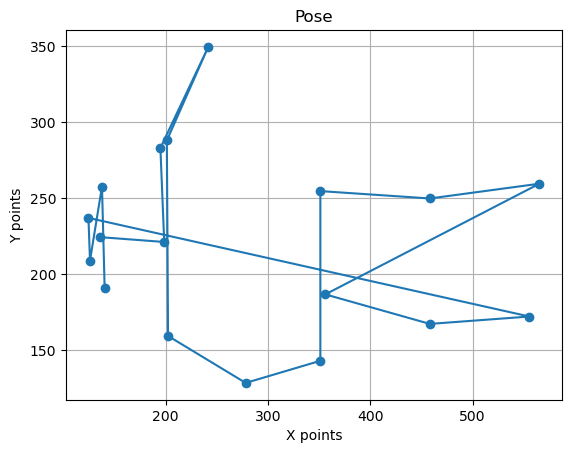

In [ ]:
plot_pose(df.iloc[0])

In [6]:
from google.colab import files
uploaded = files.upload()


Saving Test_features.csv to Test_features.csv
Saving Test_labels.csv to Test_labels.csv
Saving Test_skelletonpoints.csv to Test_skelletonpoints.csv
Saving Train_features.csv to Train_features.csv
Saving Train_labels.csv to Train_labels.csv
Saving Train_skelletonpoints.csv to Train_skelletonpoints.csv


In [46]:
train_X    = pd.read_csv('Train_features.csv',       header=None)
test_X     = pd.read_csv('Test_features.csv',        header=None)

# 2) Puntos de esqueleto
skel_train = pd.read_csv('Train_skelletonpoints.csv', header=None, sep=',')
skel_test  = pd.read_csv('Test_skelletonpoints.csv',  header=None, sep=',')

train_y = pd.read_csv('Train_labels.csv', header=None, sep=',')
train_y = train_y.T[0]     # ahora train_y es una Serie de tamaño (1000,)

test_y  = pd.read_csv('Test_labels.csv', header=None, sep=',')
test_y  = test_y.T[0]      # Serie de tamaño (200,)



# 4) Comprobación de shapes
print("train_X:   ", train_X.shape)    # (1000, 270)
print("train_y:   ", train_y.shape)    # (1000, 1)
print("skel_train:", skel_train.shape) # (1000, 54)
print("test_X:    ", test_X.shape)     # (200, 270)
print("test_y:    ", test_y.shape)     # (200, 1)
print("skel_test: ", skel_test.shape)  # (400, 54)

train_X:    (1000, 270)
train_y:    (1000,)
skel_train: (1000, 54)
test_X:     (200, 270)
test_y:     (200,)
skel_test:  (400, 54)


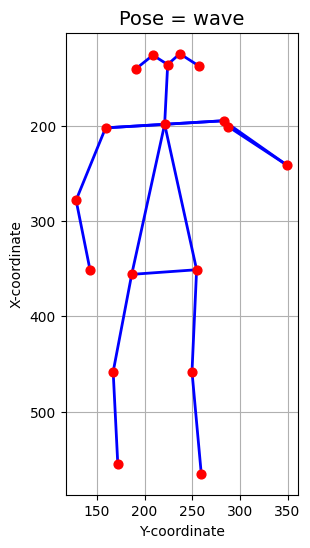

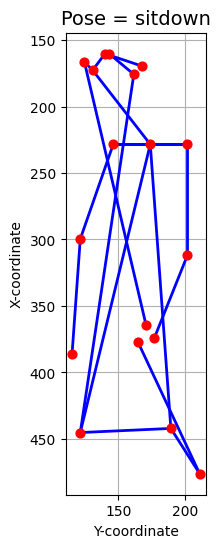

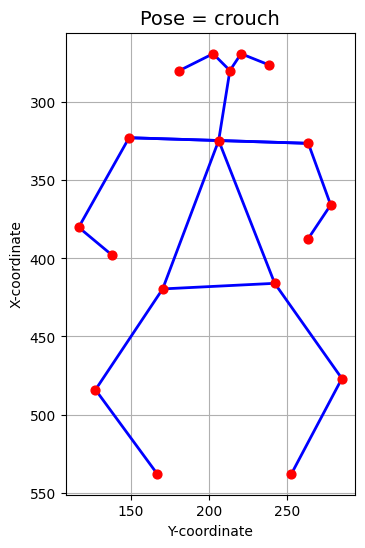

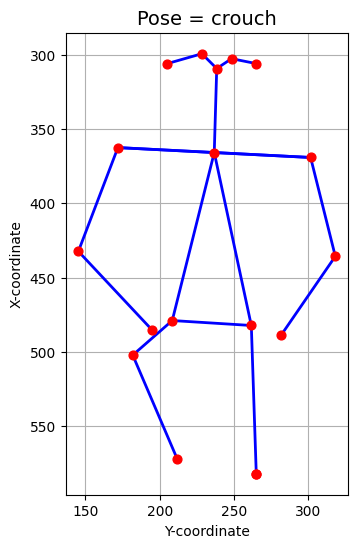

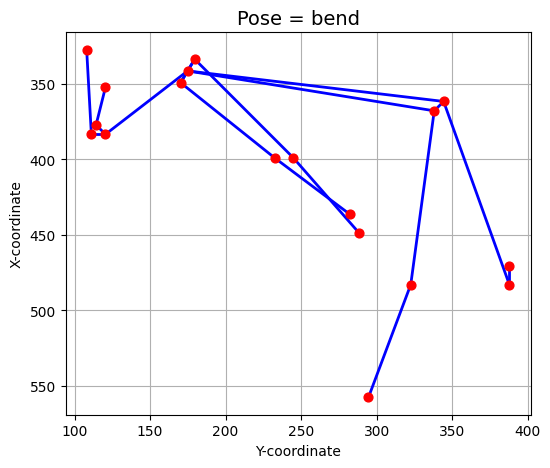

In [47]:
connections = [
    (0, 1),   # 1–2  Nose – Neck
    (1, 2),   # 2–3  Neck – Right Shoulder
    (2, 3),   # 3–4  Right Shoulder – Right Elbow
    (3, 4),   # 4–5  Right Elbow – Right Wrist
    (1, 5),   # 2–6  Neck – Left Shoulder
    (5, 6),   # 6–7  Left Shoulder – Left Elbow
    (6, 7),   # 7–8  Left Elbow – Left Wrist
    (1, 8),   # 2–9  Neck – Right Hip
    (8, 9),   # 9–10 Right Hip – Right Knee
    (9, 10),  # 10–11 Right Knee – Right Ankle
    (1, 11),  # 2–12 Neck – Left Hip
    (11, 12), # 12–13 Left Hip – Left Knee
    (12, 13), # 13–14 Left Knee – Left Ankle
    (0, 14),  # 1–15 Nose – Right Eye
    (0, 15),  # 1–16 Nose – Left Eye
    (14, 16), # 15–17 Right Eye – Right Ear
    (15, 17), # 16–18 Left Eye – Left Ear
    (2, 5),   # 3–6  Right Shoulder – Left Shoulder
    (8, 11)   # 9–12 Right Hip – Left Hip
]

pose_map = {1:'wave', 2:'push', 3:'crouch', 4:'sitdown', 5:'bend'}

def plot_skeleton(i):
    pts = skel_train.iloc[i].values
    x   = pts[:18]
    y   = pts[18:36]
    lbl = int(train_y[i])
    name = pose_map.get(lbl, lbl)

    plt.figure(figsize=(6,6))
    for a, b in connections:
        plt.plot([y[a], y[b]], [x[a], x[b]],
                 '-', color='blue', linewidth=2)
    plt.scatter(y, x, color='red', s=40, zorder=3)

    plt.title(f'Pose = {name}', fontsize=14)
    plt.xlabel('Y-coordinate')
    plt.ylabel('X-coordinate')
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.gca().set_aspect('equal', 'box')
    plt.show()


# Prueba
plot_skeleton(0)
plot_skeleton(25)
plot_skeleton(50)
plot_skeleton(75)
plot_skeleton(100)


Part II: Model implementation
